# 11 — Hyperparameter tuning (Optuna) + chọn ngưỡng vận hành

**Bước 4 & 5 của quy trình modeling cho người mới.** Tiếp nối notebook 10 (đã chốt LightGBM, 7 feature PIT-safe, temporal split).

**Hai phần:**
1. **Tuning bằng Optuna** — tìm bộ tham số LightGBM tốt hơn, *chọn theo PR-AUC trên VAL* (không đụng test), log mọi trial lên MLflow.
2. **Threshold tuning** — mô hình cho ra *xác suất*; ta chọn **ngưỡng** biến xác suất thành quyết định chặn/không, theo điểm vận hành có nguyên tắc (FPR=1%), không phải 0.5 tuỳ tiện.

> **Exploratory / non-promotable.** Đây là notebook *học quy trình*. Dự án (AGENTS.md §5/§6) mặc định không dùng Optuna cho đường promotable — bản chốt contract chạy ở `training/` với candidate matrix deterministic + manifest. Ở đây Optuna chỉ để **học cách search tham số đúng cách**. Tag MLflow `manifest_backed=false`.

**Nguyên tắc vàng:** *tuning và chọn ngưỡng CHỈ được nhìn VAL.* TEST chỉ mở một lần ở notebook 12. Vi phạm điều này = rò rỉ, điểm đẹp giả.

📖 **Cell dưới — Setup.** Y hệt notebook 10: import, resolve đường dẫn Gold/labels, định nghĩa `DEPLOYABLE_CORE` (7 feature). In `READY`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from pit_fintech.config import get_settings
from pit_fintech.data.paysim import connect_paysim, find_paysim_csv, resolve_project_root
from pit_fintech.features.paysim_specs import PAYSIM_MODEL_FEATURE_ORDER

PIT12 = list(PAYSIM_MODEL_FEATURE_ORDER)
DEPLOYABLE_CORE = [
    "current_amount",
    "transaction_type_transfer",
    "pit_prior_amount_1h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_prior_count_1h",
    "pit_prior_count_24h",
]
assert all(f in PIT12 for f in DEPLOYABLE_CORE), "core feature name drift vs contract"

PROJECT_ROOT = resolve_project_root(Path.cwd())
settings = get_settings()
data_root = settings.data_root
if not data_root.is_absolute():
    data_root = PROJECT_ROOT / data_root
artifact_root = settings.artifact_root
if not artifact_root.is_absolute():
    artifact_root = PROJECT_ROOT / artifact_root

paysim_csv = find_paysim_csv(PROJECT_ROOT)
gold_base = data_root / "lakehouse" / "paysim1"
gold_candidates = (
    sorted(gold_base.glob("*/gold/pre_decision_features")) if gold_base.exists() else []
)
GOLD_PRE_PATH = next((p for p in gold_candidates if (p / "_delta_log").exists()), None)

LABELS_PATH = None
try:
    from pit_fintech.data.paysim_lakehouse import (
        ApplicationLakehouseManifest,
        _resolve_manifest_path,
        find_latest_paysim_lakehouse_manifest,
    )

    manifest_path = find_latest_paysim_lakehouse_manifest(artifact_root)
    if manifest_path is not None:
        manifest = ApplicationLakehouseManifest.model_validate_json(
            manifest_path.read_text(encoding="utf-8")
        )
        for snap in manifest.tables:
            if snap.table == "paysim_labels":
                LABELS_PATH = _resolve_manifest_path(snap.path, PROJECT_ROOT)
                break
except Exception as exc:
    print(f"label resolution skipped: {exc}")

READY = (
    paysim_csv is not None
    and GOLD_PRE_PATH is not None
    and LABELS_PATH is not None
    and (LABELS_PATH / "_delta_log").exists()
)
print({"gold_pre": GOLD_PRE_PATH is not None, "labels": LABELS_PATH is not None, "ready": READY})

{'gold_pre': True, 'labels': True, 'ready': True}


## Execution control

📖 **Cell dưới.** `RUN_TUNING` gate cho phần nặng (Optuna). `N_TRIALS=30` là ngân sách nhỏ hợp lý cho người mới trên CPU. `MLFLOW` bật để log mọi trial. Đổi `FEATURES` nếu muốn tune trên bộ 11/12.

In [2]:
RUN_TUNING = True
SEED = 20_260_727
FEATURES = DEPLOYABLE_CORE
N_TRIALS = 30

LOG_TO_MLFLOW = True
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
MLFLOW_EXPERIMENT = "pit-fintech-notebook-exploration"
print(f"feature set = {len(FEATURES)} cột | N_TRIALS={N_TRIALS} | mlflow={LOG_TO_MLFLOW}")

feature set = 7 cột | N_TRIALS=30 | mlflow=True


📖 **Cell dưới — Nạp `frame` + tách 3 split** theo `step` (train ≤520 / val 521–631 / test ≥632). DuckDB join có `ORDER BY` để tái lập. In prevalence mỗi split.

In [3]:
frame = splits = None
if RUN_TUNING and READY:
    from deltalake import DeltaTable

    gold = DeltaTable(str(GOLD_PRE_PATH)).to_pyarrow_table()
    labels = (
        DeltaTable(str(LABELS_PATH)).to_pyarrow_table().select(["source_row_number", "isFraud"])
    )
    connection = connect_paysim(paysim_csv)
    connection.register("gold", gold)
    connection.register("labels", labels)
    pit_cols = ", ".join(f"g.{name}" for name in PIT12)
    frame = connection.execute(
        f"SELECT g.source_row_number, g.step, l.isFraud, {pit_cols} "
        "FROM gold AS g JOIN labels AS l USING (source_row_number) "
        "ORDER BY g.source_row_number"
    ).df()
    connection.close()
    frame[PIT12] = frame[PIT12].astype("float64")

    train_df = frame[frame["step"] <= 520]
    val_df = frame[(frame["step"] >= 521) & (frame["step"] <= 631)]
    test_df = frame[frame["step"] >= 632]
    splits = {"train": train_df, "val": val_df, "test": test_df}
    rows = [
        {
            "split": s,
            "rows": len(p),
            "fraud": int(p["isFraud"].sum()),
            "prevalence": round(int(p["isFraud"].sum()) / max(len(p), 1), 6),
        }
        for s, p in splits.items()
    ]
    display(pd.DataFrame(rows))
else:
    print("Skipped: set RUN_TUNING = True (và data phải READY).")

,split,rows,fraud,prevalence
0,train,2653729,5781,0.002178
1,val,78701,1180,0.014993
2,test,37979,1252,0.032966


## Phần A · Tuning bằng Optuna

📖 **Vì sao Optuna, không Grid/Random Search?** Grid Search thử *mọi tổ hợp* → bùng nổ tổ hợp, cực chậm. Optuna dùng **TPE** (Tree-structured Parzen Estimator): học từ các trial trước để *đề xuất vùng tham số hứa hẹn* → tìm tốt hơn với ít lần thử hơn. Với `sampler=TPESampler(seed=SEED)` thì **tái lập được**.

📖 **Search gì và vì sao (LightGBM):**

| Tham số | Vai trò | Khoảng thử |
|---|---|---|
| `n_estimators` | số cây | 150–500 |
| `learning_rate` | tốc độ học (nhỏ = chậm mà chắc) | 0.01–0.1 (log) |
| `num_leaves` | độ phức tạp mỗi cây (lớn = dễ overfit) | 15–63 |
| `max_depth` | chiều sâu tối đa | 3–10 |
| `min_child_samples` | số mẫu tối thiểu mỗi lá (lớn = regularize mạnh) | 20–100 |
| `subsample` | tỷ lệ lấy mẫu **dòng** mỗi vòng (chống overfit) | 0.6–1.0 |
| `colsample_bytree` | tỷ lệ lấy mẫu **cột** mỗi cây | 0.6–1.0 |
| `reg_lambda` | phạt L2 (chống overfit) | 1e-3–10 (log) |

**`scale_pos_weight` KHÔNG tune** — cố định ở `√(neg/pos)` đã validate ở nb10. Dùng full `neg/pos` làm bão hoà xác suất (log_loss 9.39) — ta không lặp lại lỗi đó.

📖 **Cell dưới — Chạy study.** Mỗi trial: fit LightGBM với tham số Optuna gợi ý → tính **PR-AUC trên VAL** → đó là điểm để tối đa hoá. Mỗi trial log 1 nested run lên MLflow. Cũng đo **baseline** (config mặc định nb10) để thấy tuning cải thiện bao nhiêu.

In [6]:
study = best_model = baseline_val_ap = None
if splits is not None:
    import lightgbm as lgb
    from sklearn.metrics import average_precision_score

    pos = int((train_df["isFraud"] == 1).sum())
    neg = int((train_df["isFraud"] == 0).sum())
    spw = float(np.sqrt(neg / max(pos, 1)))  # validated: sqrt, KHONG phai neg/pos
    Xtr, ytr = train_df[FEATURES], train_df["isFraud"]
    Xval, yval = val_df[FEATURES], val_df["isFraud"].to_numpy()

    FIXED = dict(
        objective="binary",
        scale_pos_weight=spw,
        subsample_freq=1,
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )

    # baseline = config mac dinh notebook 10
    base = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        reg_lambda=1.0,
        **FIXED,
    )
    base.fit(Xtr, ytr)
    baseline_val_ap = float(average_precision_score(yval, base.predict_proba(Xval)[:, 1]))
    print(f"spw (sqrt) = {spw:.4f}  |  BASELINE val PR-AUC = {baseline_val_ap:.6f}")

    mlflow = None
    if LOG_TO_MLFLOW:
        try:
            import mlflow as _mlflow

            _mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
            _mlflow.set_experiment(MLFLOW_EXPERIMENT)
            mlflow = _mlflow
        except Exception as exc:
            print(f"mlflow off ({exc}); van chay, chi khong log.")

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 150, 500, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            num_leaves=trial.suggest_int("num_leaves", 15, 63),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            min_child_samples=trial.suggest_int("min_child_samples", 20, 100),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        )
        mdl = lgb.LGBMClassifier(**params, **FIXED)
        mdl.fit(Xtr, ytr)
        ap = float(average_precision_score(yval, mdl.predict_proba(Xval)[:, 1]))
        if mlflow is not None:
            with mlflow.start_run(nested=True, run_name=f"trial-{trial.number}"):
                mlflow.log_params(params)
                mlflow.log_metric("val_pr_auc", ap)
                mlflow.set_tags(
                    {
                        "surface": "notebook-exploratory",
                        "manifest_backed": "false",
                        "stage": "optuna-trial",
                    }
                )
        return ap

    import optuna

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    parent_ctx = mlflow.start_run(run_name="nb11-tuning") if mlflow is not None else None
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    if mlflow is not None:
        mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
        mlflow.log_metric("baseline_val_pr_auc", baseline_val_ap)
        mlflow.log_metric("best_val_pr_auc", study.best_value)
        mlflow.set_tags(
            {
                "surface": "notebook-exploratory",
                "manifest_backed": "false",
                "stage": "optuna-study",
                "n_trials": N_TRIALS,
            }
        )
        mlflow.end_run()
    print(
        f"BEST val PR-AUC = {study.best_value:.6f}  (baseline {baseline_val_ap:.6f}, "
        f"gain {study.best_value - baseline_val_ap:+.6f})"
    )
else:
    print("Skipped: enable RUN_TUNING above.")

spw (sqrt) = 21.4019  |  BASELINE val PR-AUC = 0.300063
🏃 View run trial-0 at: http://127.0.0.1:5000/#/experiments/6/runs/b35bdfbbc48b4d36b58acf7819734a09
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run trial-1 at: http://127.0.0.1:5000/#/experiments/6/runs/49eca01866dc430096d45aa1d32c3476
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run trial-2 at: http://127.0.0.1:5000/#/experiments/6/runs/3067a6da2c014026ac95091c61b54735
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run trial-3 at: http://127.0.0.1:5000/#/experiments/6/runs/bdb998931cd2422585e7cd0c6195dec3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run trial-4 at: http://127.0.0.1:5000/#/experiments/6/runs/7fc920630ed2463a82c62758c5119669
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run trial-5 at: http://127.0.0.1:5000/#/experiments/6/runs/aa1664c1ad8144ab83c023cba22a4d96
🧪 View experiment at: http://127.0.0.1:5000/#/expe

📖 **Cell dưới — Best params + refit.** Lấy tham số tốt nhất, fit lại `best_model` trên train. In bảng tham số để bạn **chép sang notebook 12** (đánh giá test cuối).

In [7]:
best_params = None
if study is not None:
    import lightgbm as lgb

    best_params = dict(study.best_params)
    best_model = lgb.LGBMClassifier(**best_params, **FIXED)
    best_model.fit(Xtr, ytr)
    display(pd.DataFrame([best_params]).T.rename(columns={0: "best_value"}))
    print("\nCHÉP dict này sang notebook 12 (BEST_PARAMS):")
    print(best_params)
else:
    print("Skipped: enable RUN_TUNING above.")

,best_value
n_estimators,500.000000
learning_rate,0.023050
num_leaves,38.000000
max_depth,6.000000
min_child_samples,100.000000
subsample,0.686579
colsample_bytree,0.768076
reg_lambda,5.303613



CHÉP dict này sang notebook 12 (BEST_PARAMS):
{'n_estimators': 500, 'learning_rate': 0.023049834751583245, 'num_leaves': 38, 'max_depth': 6, 'min_child_samples': 100, 'subsample': 0.6865787700518957, 'colsample_bytree': 0.7680757154795024, 'reg_lambda': 5.303612526311521}


📖 **Cách đọc kết quả tuning**
- **`gain` dương nhưng nhỏ** là chuyện *bình thường và trung thực*: với dataset đã "cạn" tín hiệu (PaySim AMBER, chỉ 7 feature), tuning hiếm khi tạo nhảy vọt. Kết luận nb10 vẫn đúng: **trần chất lượng do feature/data, không phải do tham số.**
- **Cẩn thận overfit VAL:** nếu ta thử quá nhiều trial, best-on-val có thể chỉ là *may rủi trên đúng tập val này*. Đó là lý do (a) ngân sách nhỏ, (b) con số thật phải đọc ở TEST (nb12), (c) muốn chắc thì đa-seed + CV ở `training/`.
- Vào MLflow lọc `stage=optuna-trial`, sort theo `val_pr_auc` để xem tham số nào hay đi cùng điểm cao.

## Phần B · Threshold tuning — biến xác suất thành quyết định

📖 **Vấn đề.** Model xuất *xác suất* p ∈ [0,1]. Mặc định `predict` gắn cờ fraud khi p ≥ **0.5** — nhưng 0.5 gần như luôn **sai** cho fraud mất cân bằng: rất ít giao dịch đạt 0.5 → bỏ sót hàng loạt. Ta phải **chọn ngưỡng có chủ đích**.

📖 **Ba chiến lược chọn ngưỡng (đều tính TRÊN VAL):**
1. **FPR=1%** — giữ báo động giả ở mức chịu được. *Đây là điểm vận hành mặc định của dự án* (`DEFAULT_FIXED_FPR=0.01`).
2. **Max-F1** — cân bằng precision/recall (dùng khi chưa có ràng buộc nghiệp vụ rõ).
3. **Precision ≥ target** — chốt độ chính xác tối thiểu (vd 0.70) rồi lấy recall cao nhất có thể. Hợp khi review đắt đỏ.

📖 **Cell dưới — Quét ngưỡng trên VAL** và tính precision/recall/F1/FPR tại mỗi mức. Sinh 3 ngưỡng theo 3 chiến lược trên.

In [8]:
thr_choices = None
if best_model is not None:
    from sklearn.metrics import precision_recall_curve, roc_curve

    pv = best_model.predict_proba(Xval)[:, 1]
    prec, rec, thr_pr = precision_recall_curve(yval, pv)
    # precision_recall_curve tra prec/rec dai hon thr 1 phan tu -> cat cho khop
    prec, rec = prec[:-1], rec[:-1]
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)

    # 1) FPR=1%
    fpr, tpr, thr_roc = roc_curve(yval, pv)
    ok = fpr <= 0.01
    i = int(np.max(np.where(ok)))
    t_fpr = float(thr_roc[i])

    # 2) max-F1
    t_f1 = float(thr_pr[int(np.argmax(f1))])

    # 3) precision >= 0.70 (lay recall cao nhat)
    PREC_TARGET = 0.70
    mask = prec >= PREC_TARGET
    t_prec = float(thr_pr[np.where(mask)[0][np.argmax(rec[mask])]]) if mask.any() else None

    def row(name, t):
        if t is None:
            return {"strategy": name, "threshold": None, "note": "khong dat duoc"}
        yhat = (pv >= t).astype(int)
        tp = int(((yhat == 1) & (yval == 1)).sum())
        fp = int(((yhat == 1) & (yval == 0)).sum())
        fn = int(((yhat == 0) & (yval == 1)).sum())
        p = tp / max(tp + fp, 1)
        r = tp / max(tp + fn, 1)
        return {
            "strategy": name,
            "threshold": round(t, 6),
            "precision": round(p, 6),
            "recall": round(r, 6),
            "f1": round(2 * p * r / max(p + r, 1e-12), 6),
            "TP": tp,
            "FP": fp,
            "FN": fn,
        }

    thr_choices = pd.DataFrame(
        [
            row("FPR<=1% (mac dinh du an)", t_fpr),
            row("max-F1", t_f1),
            row(f"precision>={PREC_TARGET}", t_prec),
        ]
    )
    display(thr_choices)
    CHOSEN_THRESHOLD = t_fpr
    print(f"\n>> Ngưỡng chốt (điểm vận hành dự án, FPR<=1%): {CHOSEN_THRESHOLD:.6f}")
    print(">> CHÉP số này sang notebook 12 (CHOSEN_THRESHOLD).")
else:
    print("Skipped: enable RUN_TUNING above.")

,strategy,threshold,precision,recall,f1,TP,FP,FN
0,FPR<=1% (mac dinh du an),0.595365,0.309157,0.288983,0.298730,341,762,839
1,max-F1,0.720149,0.610619,0.233898,0.338235,276,176,904
2,precision>=0.7,0.757902,0.927966,0.185593,0.309322,219,17,961



>> Ngưỡng chốt (điểm vận hành dự án, FPR<=1%): 0.595365
>> CHÉP số này sang notebook 12 (CHOSEN_THRESHOLD).


📖 **Cell dưới — Đường đánh đổi Precision/Recall/F1 theo ngưỡng** (trên VAL) + đánh dấu 3 ngưỡng đã chọn. Nhìn để *thấy* trực giác: kéo ngưỡng xuống → recall lên, precision xuống.

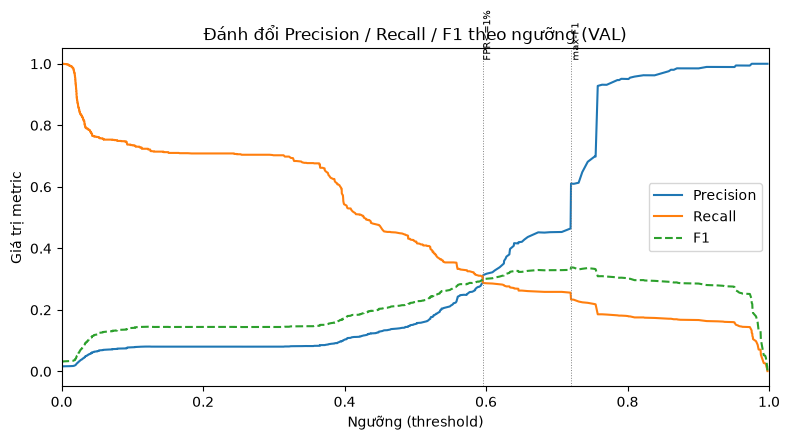

In [9]:
if best_model is not None:
    try:
        import matplotlib.pyplot as plt

        order = np.argsort(thr_pr)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.plot(thr_pr[order], prec[order], label="Precision")
        ax.plot(thr_pr[order], rec[order], label="Recall")
        ax.plot(thr_pr[order], f1[order], label="F1", ls="--")
        for t, name in [(t_fpr, "FPR<=1%"), (t_f1, "max-F1")]:
            ax.axvline(t, color="grey", lw=0.7, ls=":")
            ax.text(t, 1.01, name, fontsize=7, rotation=90, va="bottom")
        ax.set_xlabel("Ngưỡng (threshold)")
        ax.set_ylabel("Giá trị metric")
        ax.set_title("Đánh đổi Precision / Recall / F1 theo ngưỡng (VAL)")
        ax.set_xlim(0, 1)
        ax.legend()
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; dung bang o tren.")
else:
    print("Skipped: enable RUN_TUNING above.")

## Kết luận notebook 11

- **Tuning (Optuna)** chọn tham số theo **PR-AUC trên VAL**, log mọi trial lên MLflow, `scale_pos_weight` giữ nguyên `√(neg/pos)` đã validate. Gain thường nhỏ → đúng với kết luận "trần do feature/data".
- **Threshold tuning** cho thấy 0.5 là vô lý; ta chốt ngưỡng ở **điểm vận hành FPR=1%** của dự án. Ba chiến lược để bạn thấy sự đánh đổi.
- **Bàn giao sang notebook 12:** `BEST_PARAMS` (in ở Phần A) + `CHOSEN_THRESHOLD` (Phần B). Notebook 12 mới được mở TEST — đánh giá cuối + SHAP + report.
- Đây là surface **exploratory**; bản chốt promotable chạy ở `training/` với candidate matrix deterministic + manifest + đa seed (AGENTS §5/§6).